In [4]:
from supabase import create_client
import pandas as pd
url = "https://hlaazlqgqymhbaimgtdy.supabase.co"
key = "sb_publishable_Cd6OPLfuWq6UoaKiyiZfYA_p0fYAaL7"
supabase = create_client(url, key)

# Query a table
response = (supabase # name of data warehouse
    .table("GEData_Raw_2021_2024") # name of table
            .select("*").execute() # select all
           )

df = pd.DataFrame(response.data) # convert to dataframe

df.head() # sanity check to make sure it worked

,Artifact Code,Delivery,Goal,Subject,LO1,LO1.1,LO1.2,LO2,LO3,LO3.1,...,LO1.2.PP,LO2.PP,LO3.PP,LO3.1.PP,LO3.2.PP,LO4.PP,LO5.PP,CT:LO4+LO5.PP,Total Points Possible,Year
0,ENENGL2003001.10.pdf,RSVL Campus,A&H,ENGL,3.0,NaN,NaN,2,3.0,NaN,...,NaN,4,4,NaN,NaN,NaN,NaN,NaN,12,2021
1,HIST1503_P03_2,Concurrent,A&H,HIST,4.0,NaN,NaN,3,3.0,NaN,...,NaN,4,4,NaN,NaN,NaN,NaN,NaN,12,2024
2,POLS2003_02_03.docx,Campus,Civic Engagement,POLS,4.0,NaN,NaN,2,0.0,NaN,...,NaN,8,4,NaN,NaN,NaN,NaN,NaN,32,2022
3,AGBU2063_001_7,Campus,Critical Thinking,AGBU,2.0,NaN,NaN,4,6.0,NaN,...,NaN,8,8,NaN,NaN,8.0,8.0,16.0,36,2024
4,AGBU2063_001_8,Campus,Critical Thinking,AGBU,3.0,NaN,NaN,2,3.0,NaN,...,NaN,8,8,NaN,NaN,8.0,8.0,16.0,36,2024


In [5]:
df['Delivery'].unique()

array(['RSVL Campus', 'Concurrent', 'Campus', 'Mixed Techn.',
       'Virtual ARHS', 'Online', 'Ozark', 'Online Async', 'Hyflex',
       'Independent Study', 'Honors'], dtype=object)

In [9]:
print(df.columns.tolist())

['Artifact Code', 'Delivery', 'Goal', 'Subject', 'LO1', 'LO1.1', 'LO1.2', 'LO2', 'LO3', 'LO3.1', 'LO3.2', 'LO4', 'LO5', 'CriticalThinking_LO4+LO5', 'Rubric Score', 'LO1.PP', 'LO1.1.PP', 'LO1.2.PP', 'LO2.PP', 'LO3.PP', 'LO3.1.PP', 'LO3.2.PP', 'LO4.PP', 'LO5.PP', 'CT:LO4+LO5.PP', 'Total Points Possible', 'Year']


In [8]:
df.shape

(495, 27)

In [14]:
# create total points earned
df['TPE'] = df['LO1'] + df['LO2'] + df['LO3'] + df['LO4'] + df['LO5']
df['TPE_%'] = df['TPE'] / df['Total Points Possible']

MSE: 1.7231265804734537
R²: 0.8583951266499503
LO1   0.9319
LO3   0.0528
LO2   0.0067
LO4   0.0045
LO5   0.0040


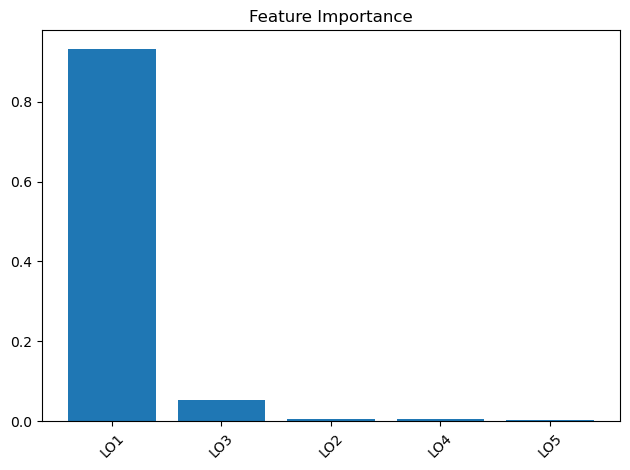

In [19]:
import pandas as pd
import numpy as np

# =========================
# Create target variables
# =========================

df['TPE'] = df[['LO1','LO2','LO3','LO4','LO5']].sum(axis=1)

df['TPE_%'] = df['TPE'] / df['Total Points Possible']

# =========================
# Features and target
# =========================

FEATURES = ["LO1","LO2","LO3","LO4","LO5"]
TARGET = "LO1.PP"

X = df[FEATURES]
y = df[TARGET]

# =========================
# Train/test split (FIXED)
# =========================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.4,
    random_state=42
)

# =========================
# Random Forest model
# =========================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=17
)

rf.fit(X_train, y_train)

# =========================
# Predictions
# =========================

preds = rf.predict(X_test)

print("MSE:", mean_squared_error(y_test, preds))
print("R²:", r2_score(y_test, preds))

# =========================
# Feature importance
# =========================

importances = rf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

for i in sorted_idx:
    print(f"{FEATURES[i]:<5} {importances[i]:.4f}")

# =========================
# Plot feature importance
# =========================

import matplotlib.pyplot as plt

plt.figure()
plt.title("Feature Importance")
plt.bar(range(len(FEATURES)), importances[sorted_idx])
plt.xticks(range(len(FEATURES)), np.array(FEATURES)[sorted_idx], rotation=45)
plt.tight_layout()
plt.show()

In [22]:
import pandas as pd
import numpy as np

VAR1 = 'Rubric Score'
VAR2 = ["LO1","LO2","LO3","LO4","LO5"]

# ------------------------
# split data
# ------------------------
np.random.seed(42)
df['r'] = np.random.uniform(size=len(df))

train = df[df["r"] <= .6].copy()
test  = df[df["r"] > .6].copy()

train.drop("r", axis=1, inplace=True)
test.drop("r", axis=1, inplace=True)

# ------------------------
# HANDLE NaNs (FIX)
# ------------------------
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

train[VAR2] = imputer.fit_transform(train[VAR2])
test[VAR2]  = imputer.transform(test[VAR2])

# ------------------------
# feature selection (LassoCV)
# ------------------------
from sklearn.linear_model import LassoCV
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler

X = train[VAR2]
y = train[VAR1]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=VAR2)

lasso = LassoCV(cv=5, random_state=42)
sfm = SelectFromModel(lasso, threshold=0.25)

sfm.fit(X_scaled, y)

selected_features = X_scaled.columns[sfm.get_support()]
print("Selected features:", list(selected_features))

# ------------------------
# OLS model
# ------------------------
import statsmodels.api as sm

X_train = sm.add_constant(train[selected_features])
y_train = train[VAR1]

reg = sm.OLS(y_train, X_train).fit()
print(reg.summary())

# ------------------------
# evaluation
# ------------------------
X_test = sm.add_constant(test[selected_features])
pred = reg.predict(X_test)

y_test = test[VAR1]

mae = np.mean(abs(y_test - pred))
rmse = np.sqrt(np.mean((y_test - pred)**2))

print("MAE:", mae)
print("RMSE:", rmse)

Selected features: ['LO1', 'LO2', 'LO3', 'LO4', 'LO5']
                            OLS Regression Results                            
Dep. Variable:           Rubric Score   R-squared:                       0.875
Model:                            OLS   Adj. R-squared:                  0.873
Method:                 Least Squares   F-statistic:                     397.0
Date:                Tue, 14 Apr 2026   Prob (F-statistic):          7.44e-126
Time:                        13:40:03   Log-Likelihood:                -716.97
No. Observations:                 290   AIC:                             1446.
Df Residuals:                     284   BIC:                             1468.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------